# Water eDNA — Database Comparison
### Lake Geneva Water Samples: PR2 vs SILVA (18S) | Porter vs MIDORI2 vs eKOI (COI)

**Purpose:** Compare how different reference databases affect taxonomy assignment on the same OTUs.  
All databases are applied to identical consensus sequences (142 18S OTUs, 195 COI OTUs).

**Run:** May 29, 2026 | isONclust3 pipeline | Q15 filter | Chimera removal

In [1]:
from scripts.notebook_utils import *
from pathlib import Path

setup_style()

BASE = Path('out/Water_eDNA_18S_COI_14_01_26')

## Methodology

**SINTAX Confidence Threshold:** All comparisons apply a confidence threshold of **0.80** (80%).
SINTAX assigns a bootstrap-like confidence value (0–1) to each taxonomic rank. Assignments below
this threshold are treated as **Unassigned** — they represent uncertain classifications that could
be misleading. A threshold of 0.80 is standard in eDNA metabarcoding studies and balances
sensitivity vs. false positive taxonomic assignments.

**Quality filtering:** Reads are filtered at **Q15** (mean quality score ≥15) during preprocessing.

**Metrics used:**
- **Assignment rate plots (bar charts):** % of OTUs confidently assigned at each rank
- **Phylum composition (pie charts):** % of total **reads** assigned to each phylum
  (weighted by abundance, not by OTU count)
- **Confidence dashboards:** Distribution of confidence scores across OTUs per rank


In [2]:
# Load all database variants
df_18s_pr2 = pd.read_csv(BASE / 'taxonomy_summary/18S/pr2/comprehensive_taxonomy_18S.csv')
df_18s_silva = pd.read_csv(BASE / 'taxonomy_summary/18S/silva/comprehensive_taxonomy_18S.csv')

df_coi_porter = pd.read_csv(BASE / 'taxonomy_summary/COI/porter/comprehensive_taxonomy_COI.csv')
df_coi_midori = pd.read_csv(BASE / 'taxonomy_summary/COI/midori2/comprehensive_taxonomy_COI.csv')
df_coi_ekoi = pd.read_csv(BASE / 'taxonomy_summary/COI/ekoi/comprehensive_taxonomy_COI.csv')

print(f"18S OTUs: {len(df_18s_pr2)} (same across DBs)")
print(f"COI OTUs: {len(df_coi_porter)} (same across DBs)")

18S OTUs: 142 (same across DBs)
COI OTUs: 195 (same across DBs)


# 18S Marker: PR2 vs SILVA

PR2 is curated for protists/eukaryotes. SILVA covers all domains (bacteria, archaea, eukaryota).
For a lake water 18S dataset, PR2 should excel at eukaryotic resolution.

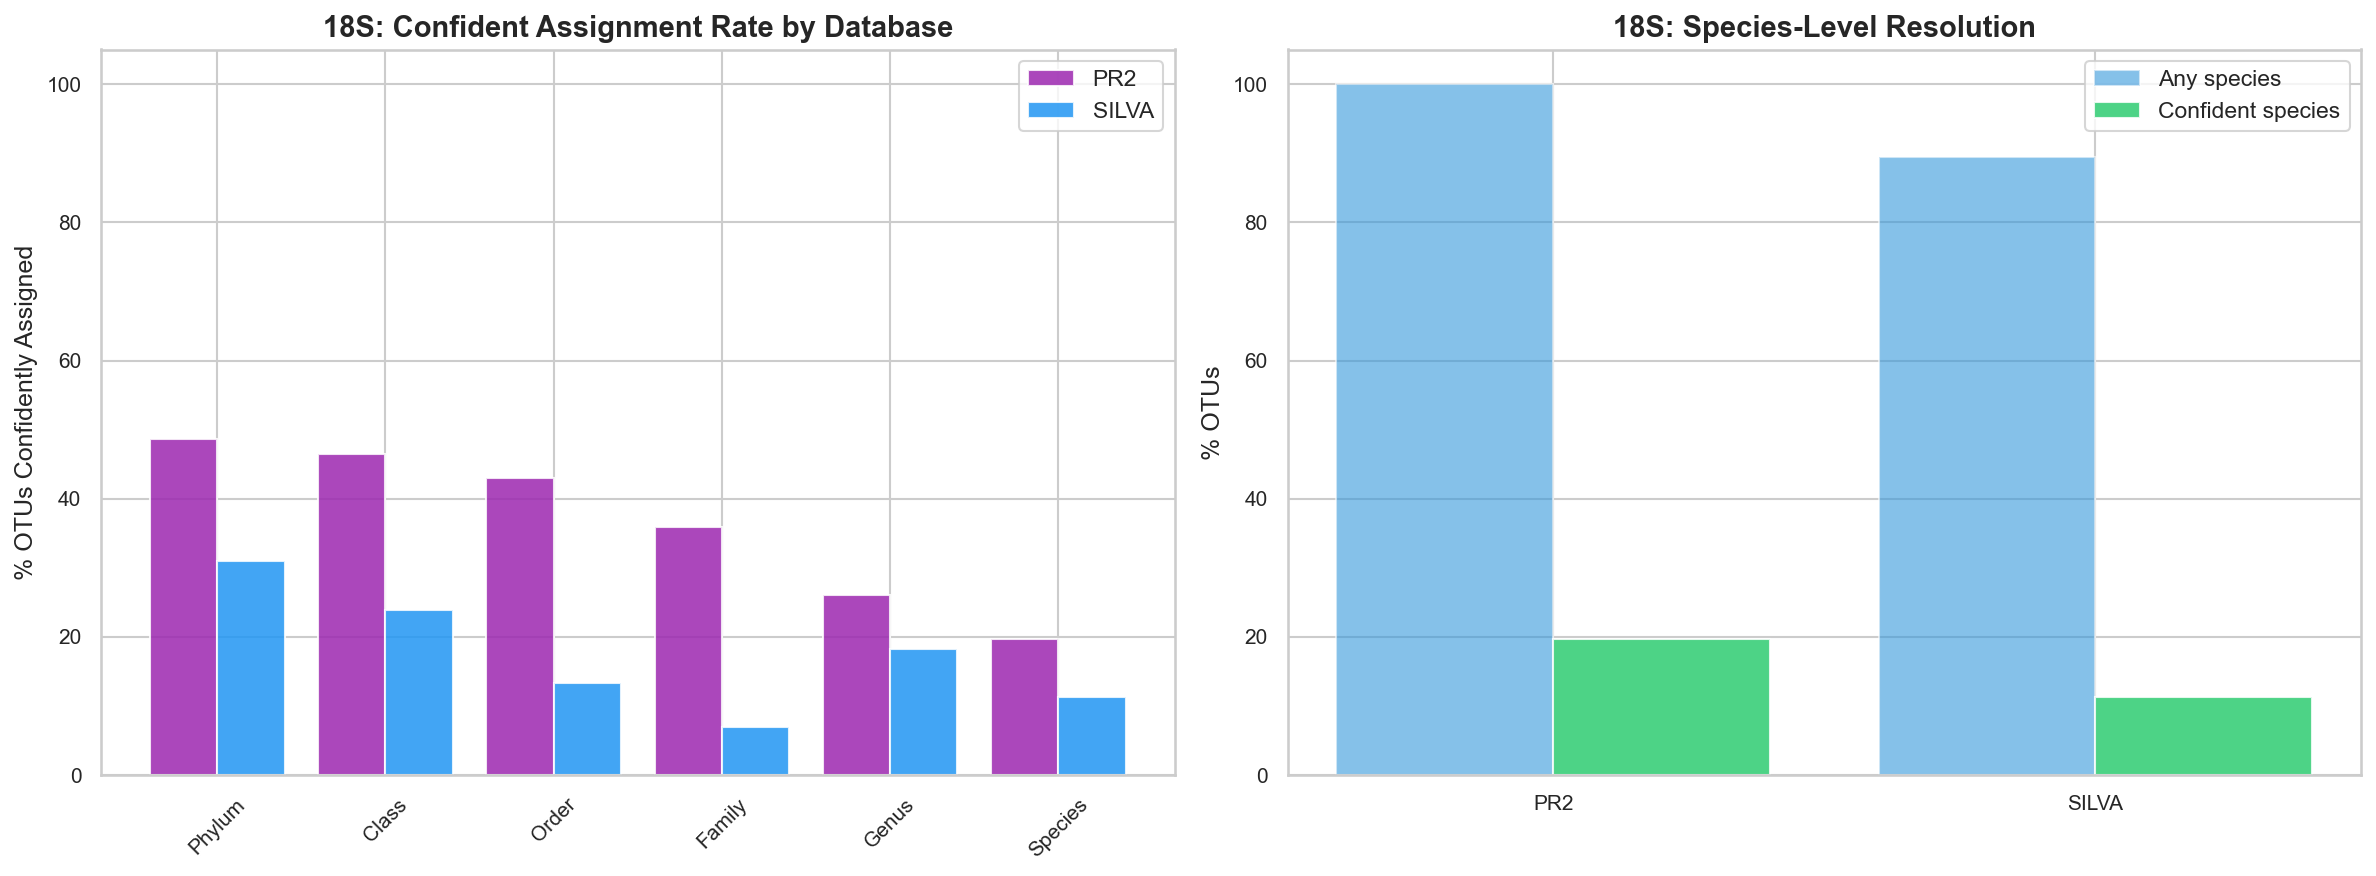

In [3]:
# Assignment rate comparison: 18S
compare_db_assignment_rates([
    (df_18s_pr2, 'PR2', 'PR2'),
    (df_18s_silva, 'SILVA', 'SILVA'),
], '18S')

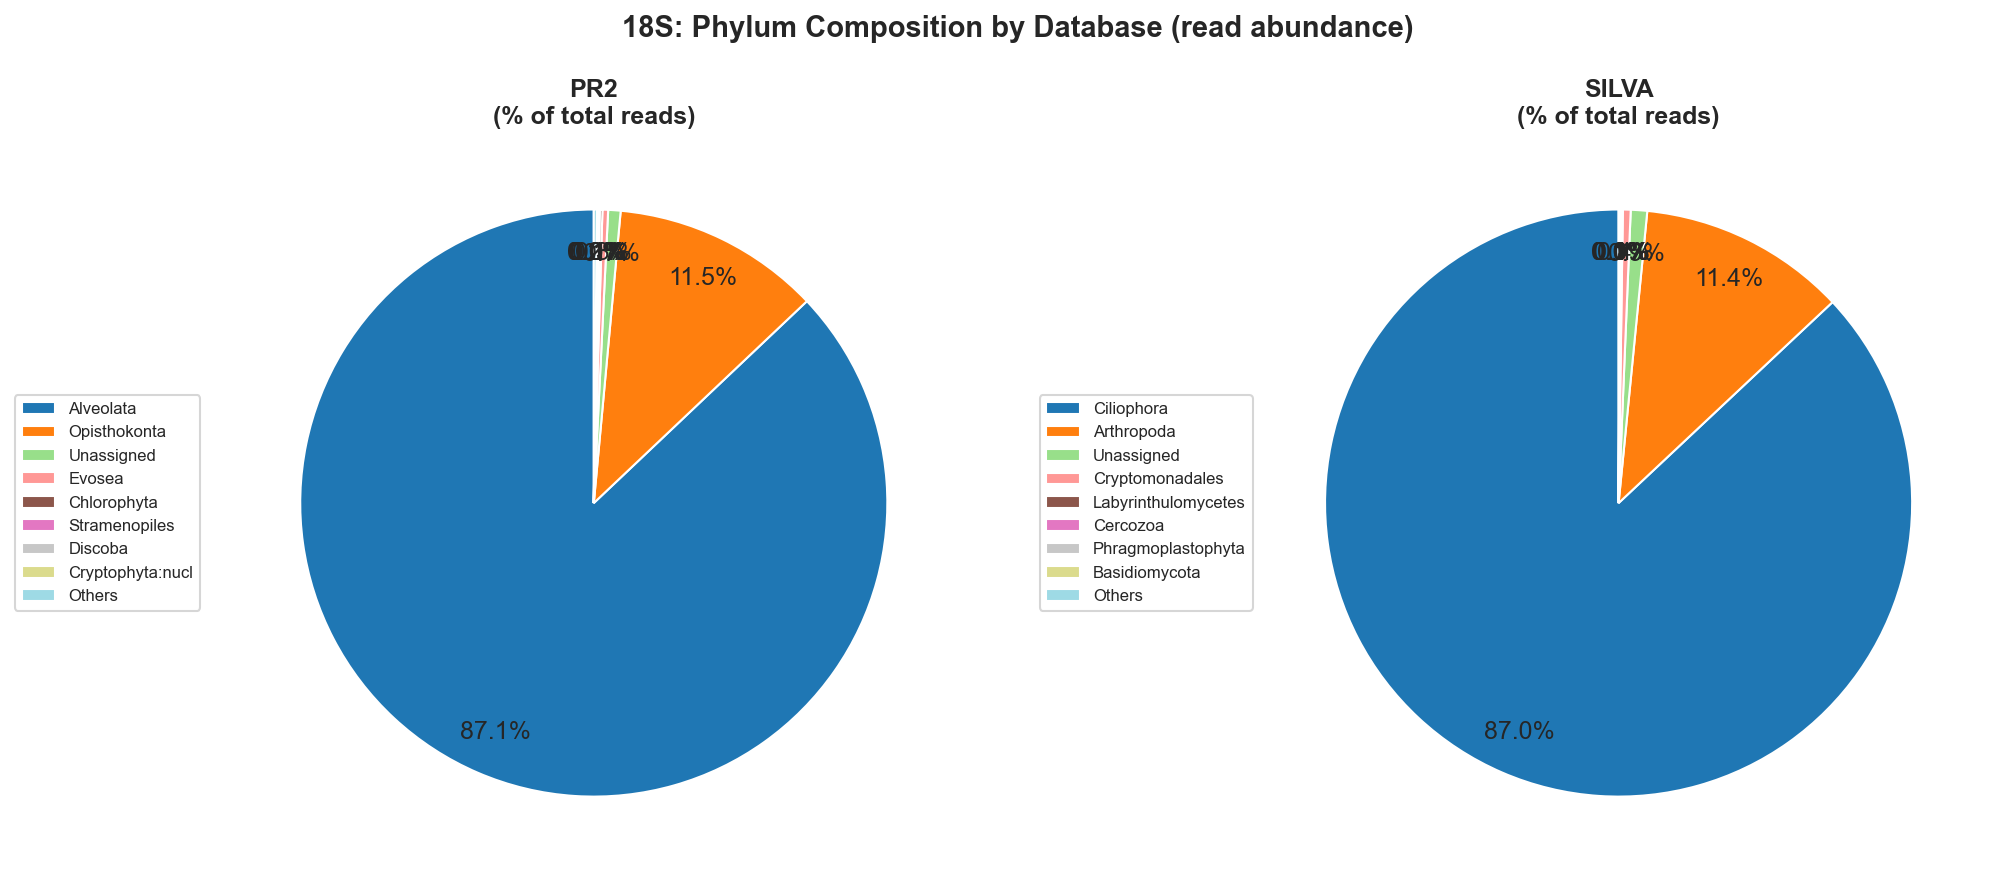

In [4]:
# Phylum composition comparison
compare_db_phylum_composition([
    (df_18s_pr2, 'PR2', 'PR2'),
    (df_18s_silva, 'SILVA', 'SILVA'),
], '18S')

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


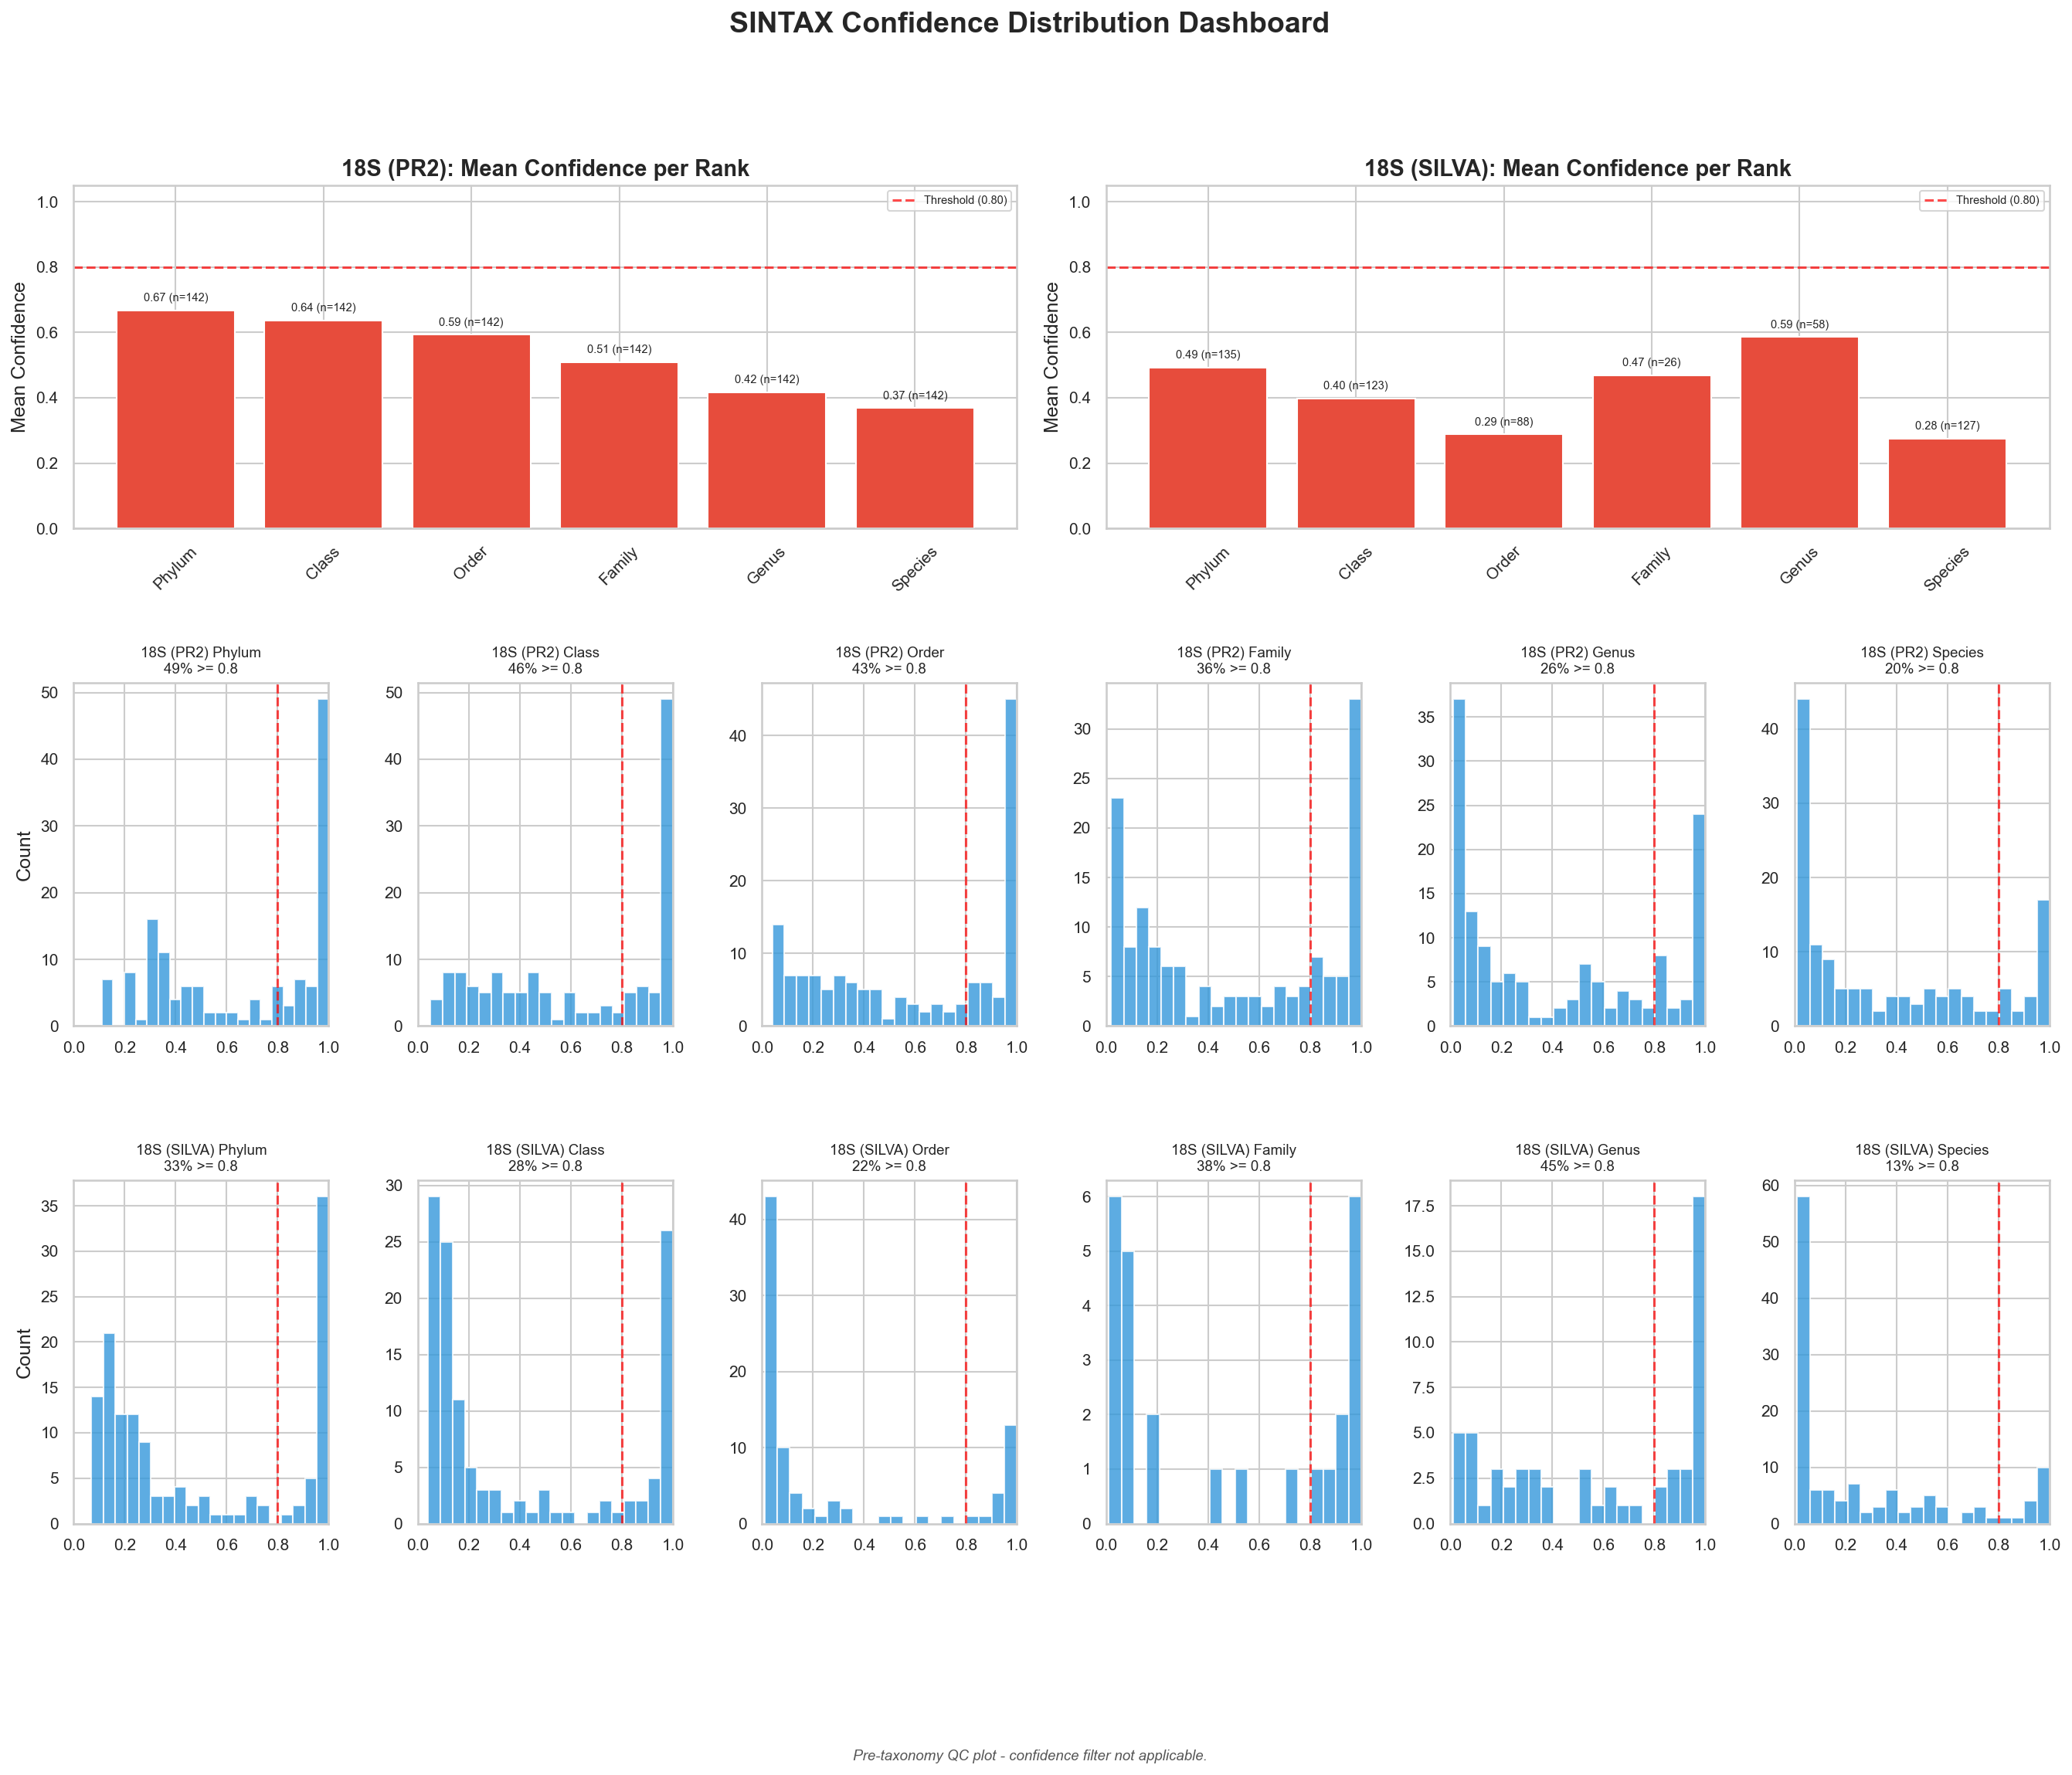

In [5]:
# Confidence dashboards side-by-side
confidence_dashboard([
    (df_18s_pr2, 'PR2', '18S (PR2)'),
    (df_18s_silva, 'SILVA', '18S (SILVA)'),
])

### 18S Summary
| Metric | PR2 | SILVA |
|--------|-----|-------|
| Curated for | Eukaryotes | All life |
| Strength | Deep protist taxonomy | Broad coverage |
| Expected winner for lake 18S | ✅ | — |

**Conclusion:** PR2 provides better resolution for lake water eukaryotes due to curated taxonomy.

# COI Marker: Porter vs MIDORI2 vs eKOI

Three databases for COI barcoding:
- **Porter:** Curated metazoan COI (conservative, high accuracy)
- **MIDORI2:** Comprehensive mitochondrial database (broad, regularly updated)
- **eKOI:** Extended Kingdom of Life Index (includes non-metazoan COI)

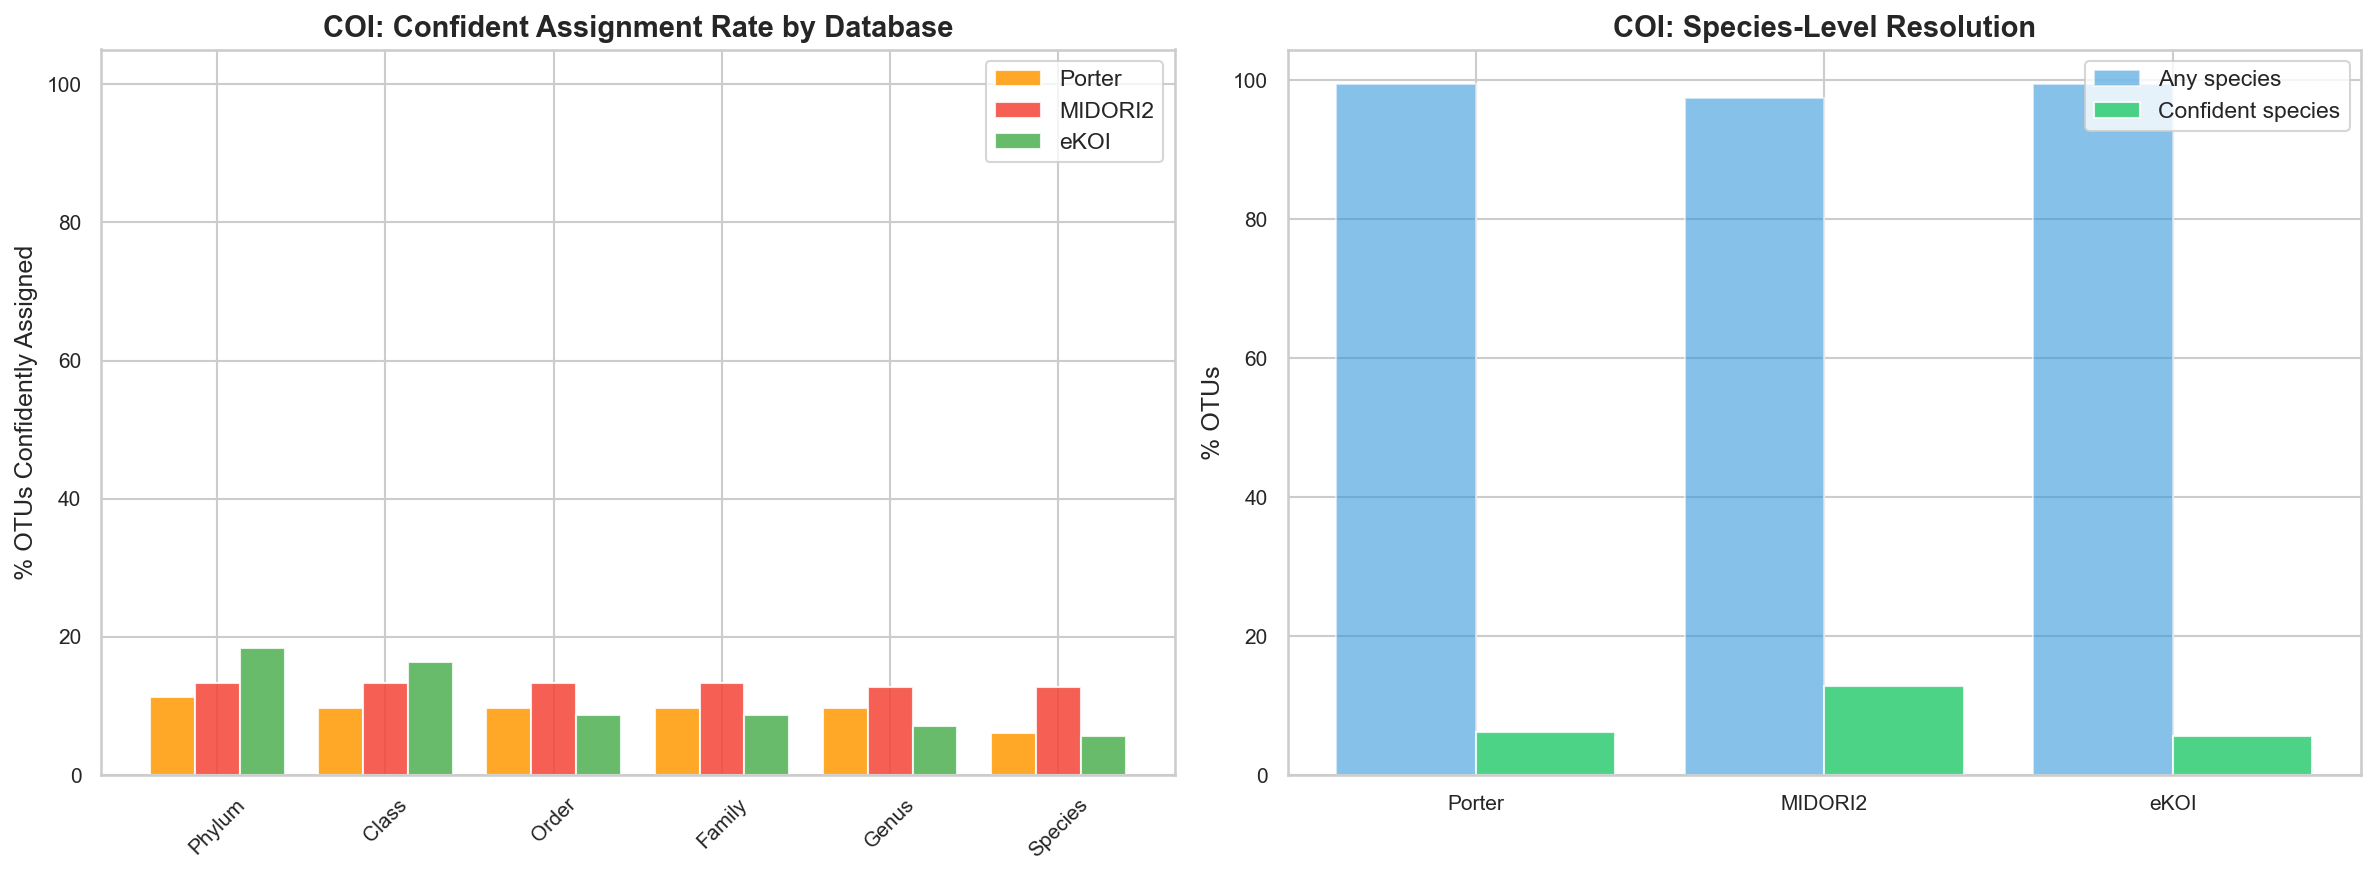

In [6]:
# Assignment rate comparison: COI
compare_db_assignment_rates([
    (df_coi_porter, 'Porter', 'Porter'),
    (df_coi_midori, 'MIDORI2', 'MIDORI2'),
    (df_coi_ekoi, 'eKOI', 'eKOI'),
], 'COI')

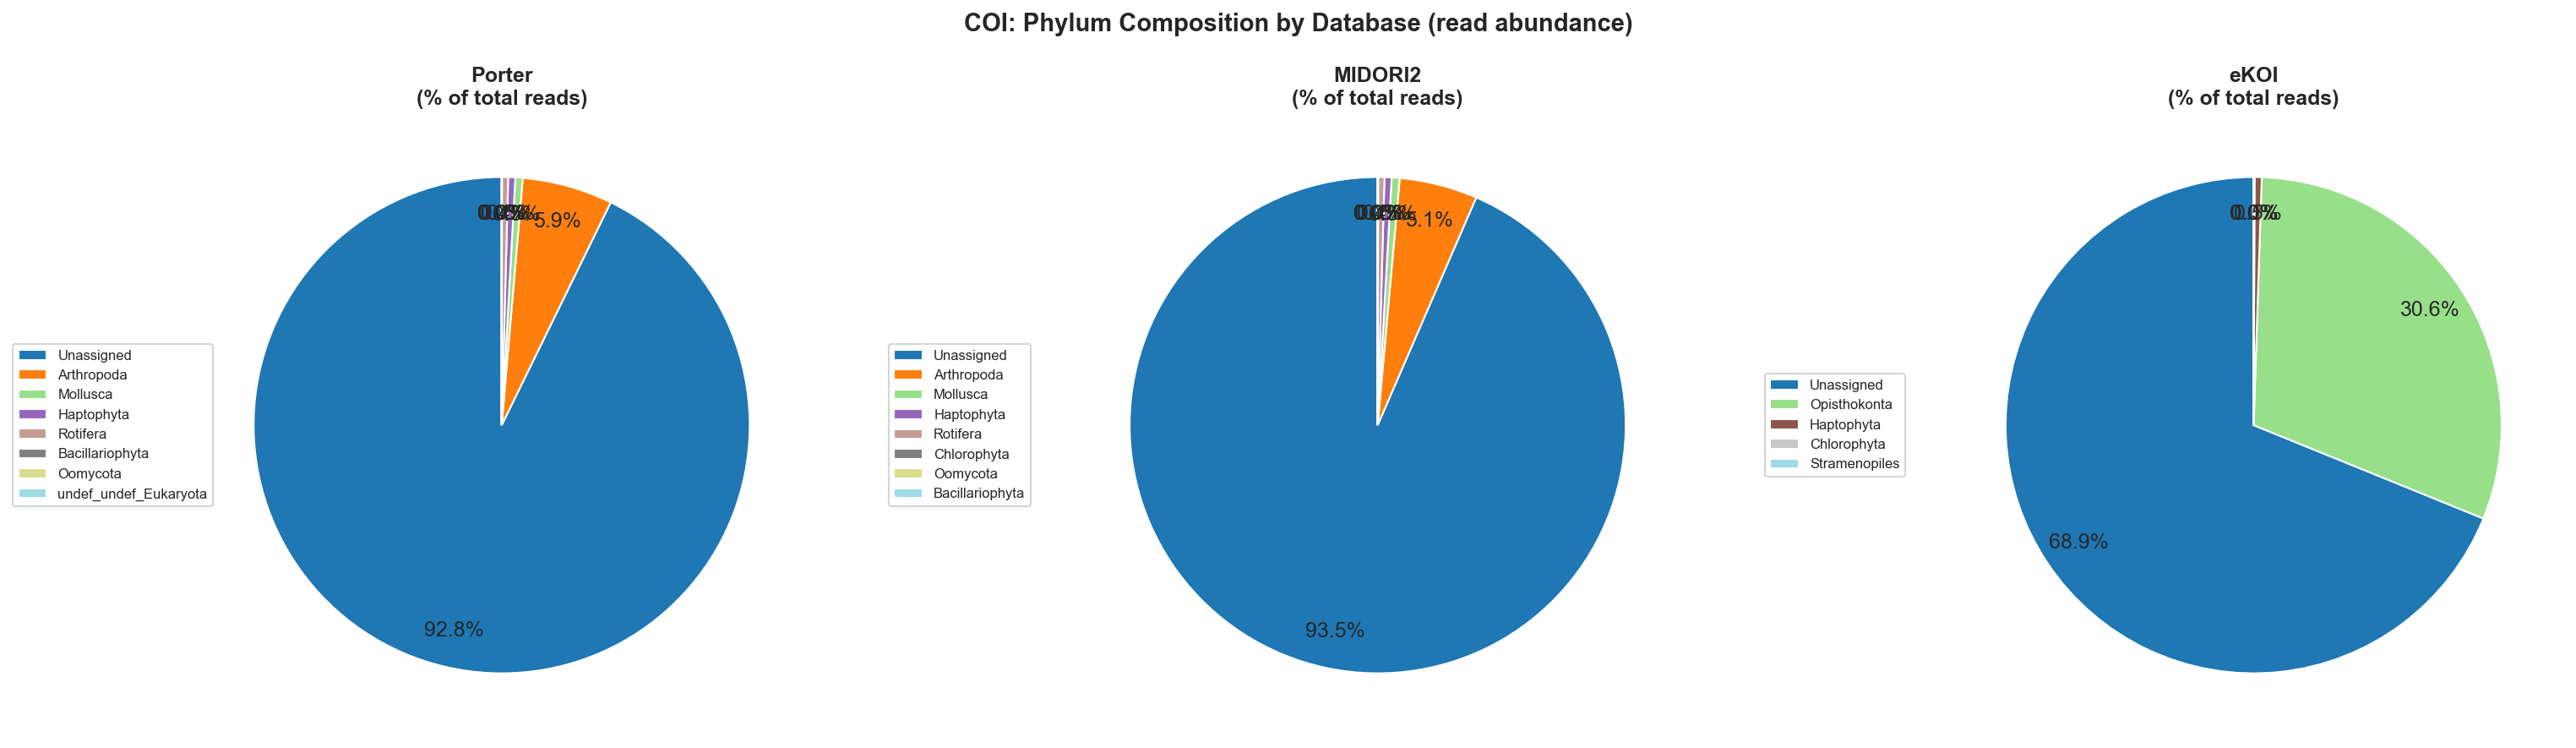

In [7]:
# Phylum composition comparison
compare_db_phylum_composition([
    (df_coi_porter, 'Porter', 'Porter'),
    (df_coi_midori, 'MIDORI2', 'MIDORI2'),
    (df_coi_ekoi, 'eKOI', 'eKOI'),
], 'COI')

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


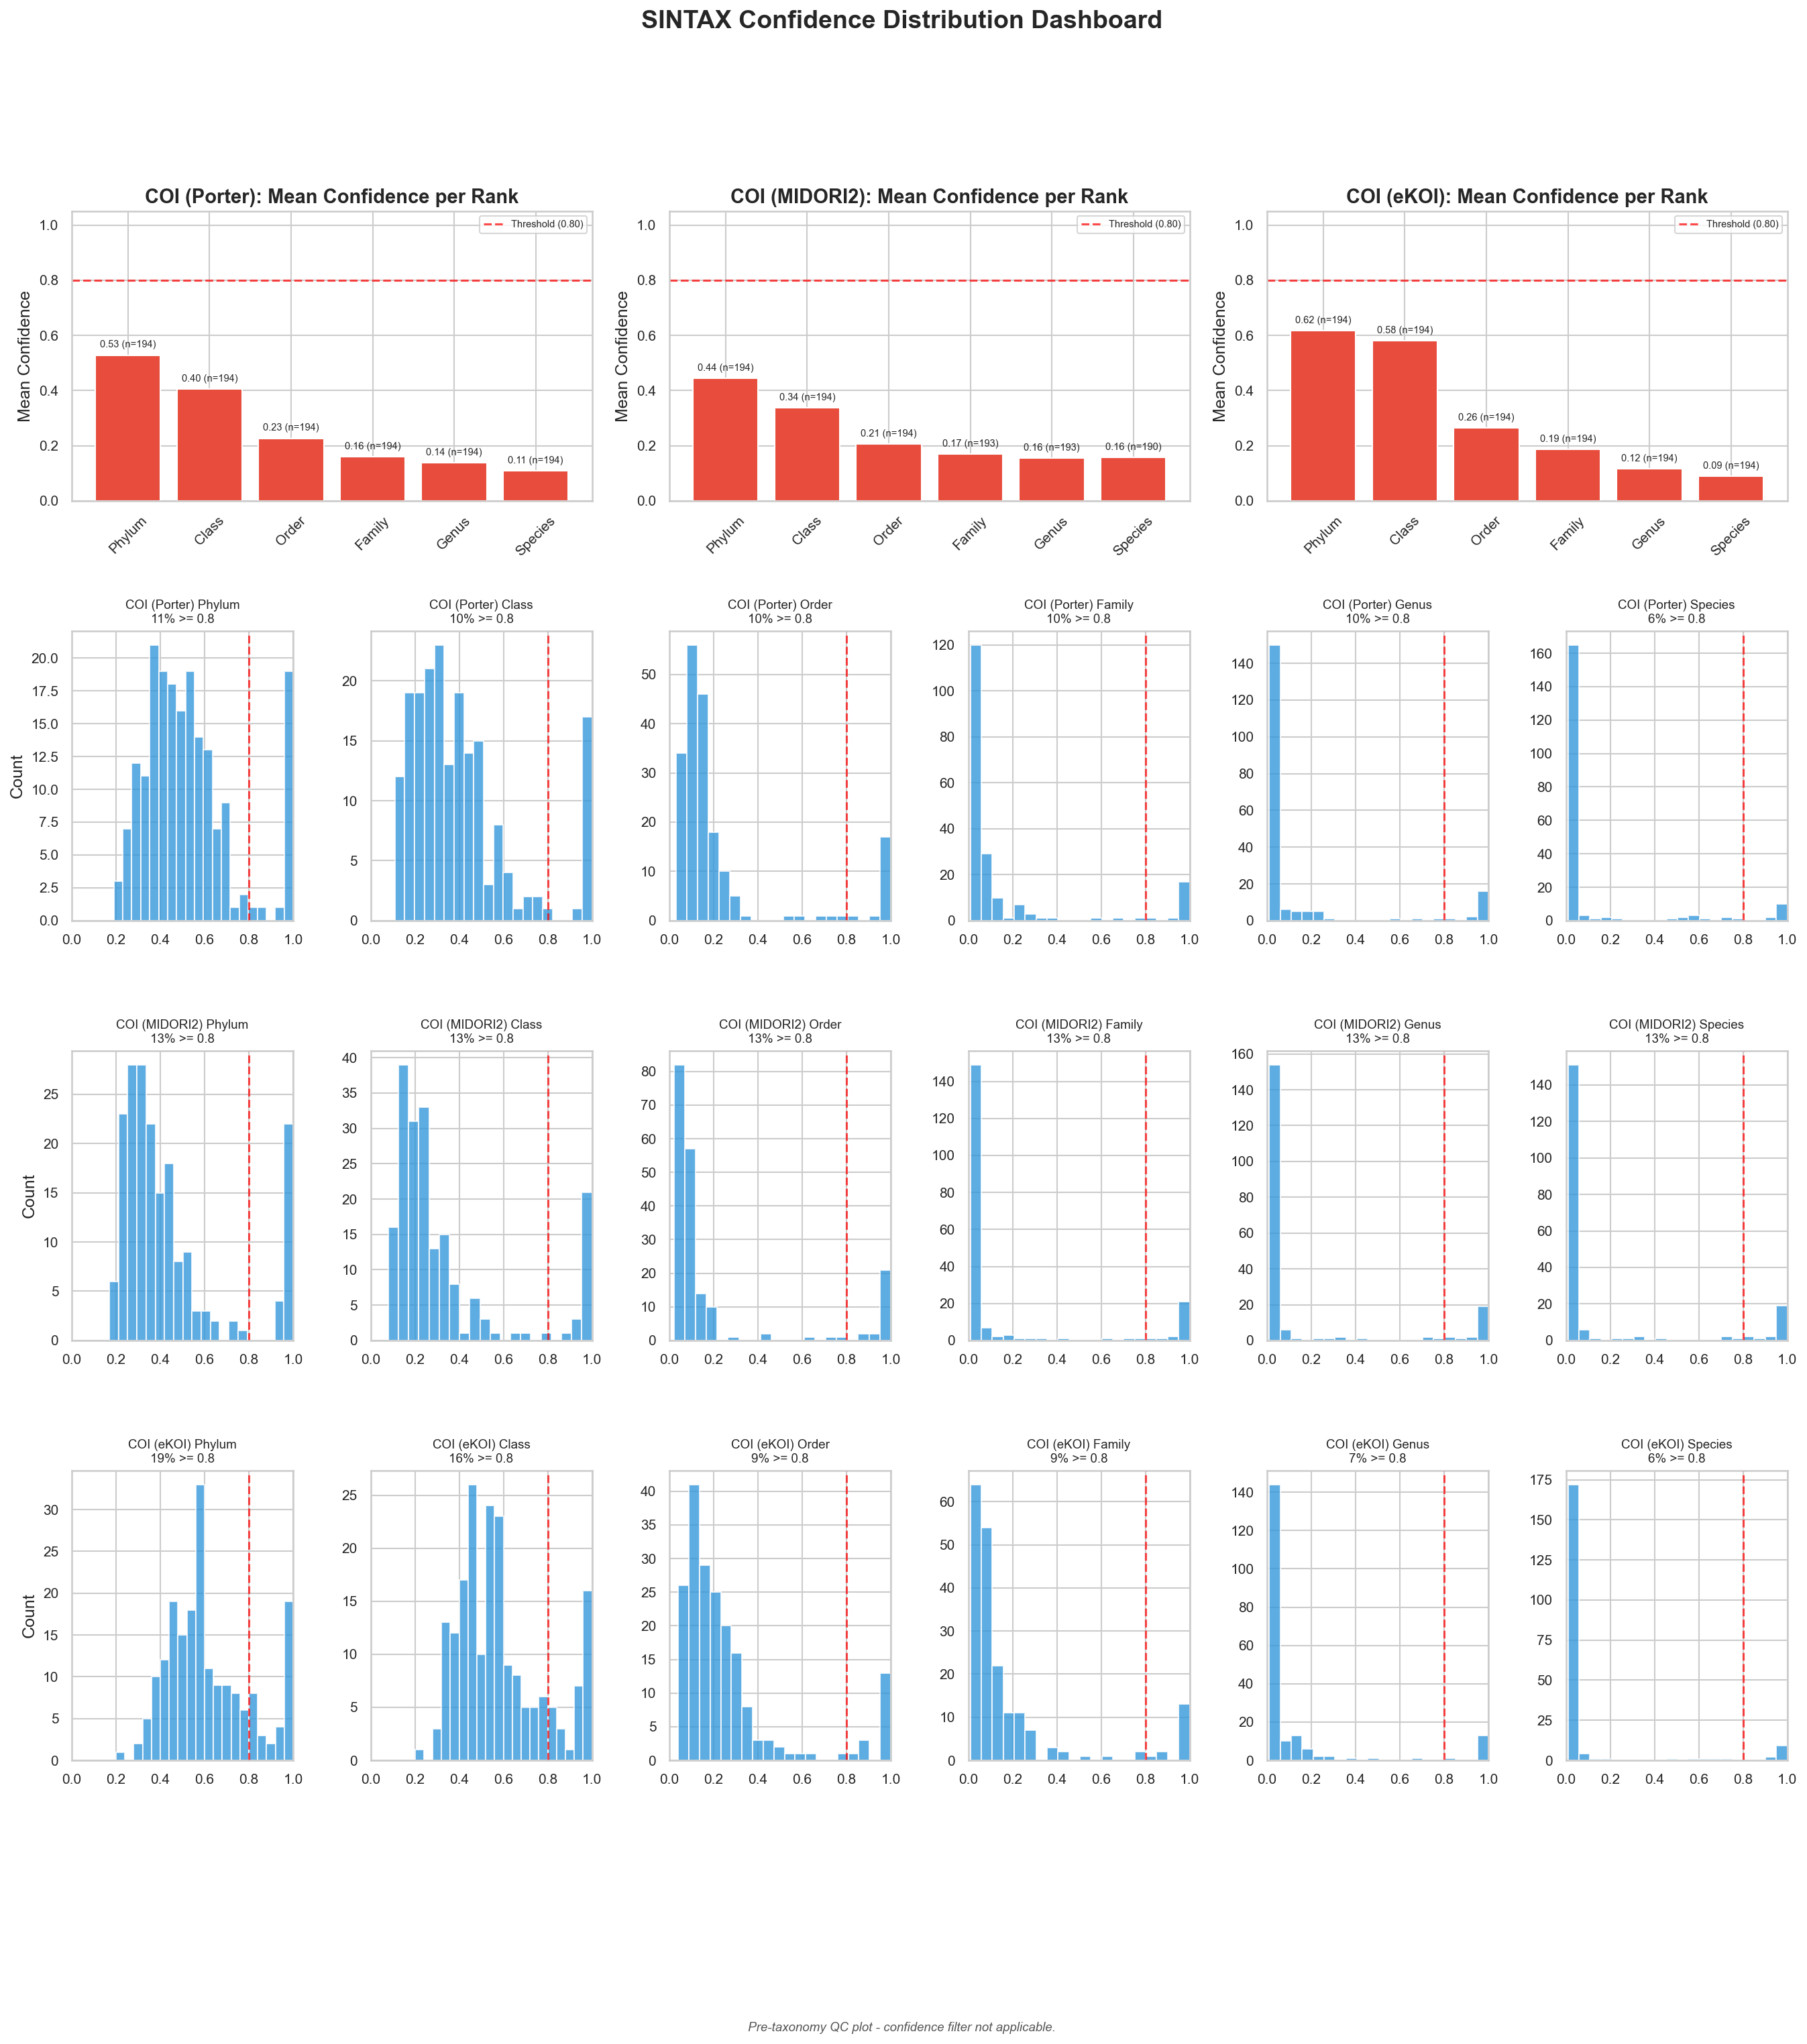

In [8]:
# Confidence comparison
confidence_dashboard([
    (df_coi_porter, 'Porter', 'COI (Porter)'),
    (df_coi_midori, 'MIDORI2', 'COI (MIDORI2)'),
    (df_coi_ekoi, 'eKOI', 'COI (eKOI)'),
])

### COI Summary
| Metric | Porter | MIDORI2 | eKOI |
|--------|--------|---------|------|
| Focus | Metazoa COI | All mito genes | Broad COI |
| Size | Small, curated | Large | Medium |
| Best for | Clean animal samples | General COI | Mixed samples |

**Conclusion:** For water COI (mostly rotifers + crustaceans), Porter and MIDORI2 perform similarly.
eKOI may catch additional non-metazoan hits.

# Recommended Database Configuration

Based on this comparison:

| Marker | Best DB | Reason |
|--------|---------|--------|
| **18S** | **PR2** | Superior eukaryotic taxonomy depth |
| **COI** | **MIDORI2** or **Porter** | Both adequate; MIDORI2 slightly broader |

These results are consistent across multiple runs and align with literature recommendations
for freshwater eDNA metabarcoding.